In [2]:
install.packages(c(
  "tidyverse",
  "psych",
  "lavaan",
  "semTools",
  "GPArotation",
  "semPlot"
))

library(tidyverse)
library(psych)
library(lavaan)
library(semTools)
library(GPArotation)
library(semPlot)
library(ggplot2)
library(reshape2)

Warning message:
"o pacote 'tidyverse' está em uso e não será instalado"
Instalando pacotes em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'psych' successfully unpacked and MD5 sums checked
package 'lavaan' successfully unpacked and MD5 sums checked
package 'semTools' successfully unpacked and MD5 sums checked
package 'GPArotation' successfully unpacked and MD5 sums checked
package 'semPlot' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\Rtmp27382Y\downloaded_packages



Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha


This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Anexando pacote: 'lavaan'


O seguinte objeto é mascarado por 'package:psych':

    cor2cov


 

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

###############################################################################


Anexando pacote: 'semTools'


Os seguintes objetos são mascarados por 'package:psych':

    reliability, skew


O seguinte objeto é mascarado por 'package:readr':

    clipboard



Anexando pacote: 'GPArotation'


Os seguintes objetos são mascarados por 'package:psych':

    equamax, varimin




ERROR: Error: carregamento do pacote ou namespace falhou para 'semPlot' in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 não há nenhum pacote chamado 'mi'


In [3]:
# =========================================================
# IMPORT DATA
# =========================================================

efa_data_raw <- read.delim(
  "adequacy-c.txt",
  check.names = FALSE
)

names(efa_data_raw) <- gsub(
  "\\.+",
  "_",
  names(efa_data_raw)
)

### Etapa 3 — Construção da matriz analítica

In [4]:
efa_data <- efa_data_raw %>%
  select(where(is.numeric))

### Etapa 4 — EFA Final (MLR)

In [5]:
efa_final <- fa(
  efa_data,
  nfactors = 5,
  fm = "ml",
  rotate = "promax"
)

print(
  efa_final,
  cut = .30,
  sort = TRUE
)

Factor Analysis using method =  ml
Call: fa(r = efa_data, nfactors = 5, rotate = "promax", fm = "ml")
Standardized loadings (pattern matrix) based upon correlation matrix
                                        item   ML2   ML5   ML1   ML4   ML3
Social_Perceptiveness_Level               12  0.94                        
Coordination_Level                        13  0.92                        
Negotiation_Level                         15  0.91                        
Persuasion_Level                          14  0.88                        
Service_Orientation_Level                 17  0.86                        
Management_of_Personnel_Resources_Level   35  0.79                        
Time_Management_Level                     32  0.74                        
Monitoring_Level                          11  0.69  0.37                  
Instructing_Level                         16  0.66  0.34                  
Learning_Strategies_Level                 10  0.58  0.39                  
Acti

### Etapa 5 — Comunalidades

In [11]:
communalities <- tibble(
  item = names(efa_data),
  h2 = efa_final$communality,
  u2 = efa_final$uniquenesses
)

### Etapa 6 — Complexidade dos Itens

In [7]:
complexity <- tibble(
  item = rownames(efa_final$loadings),
  complexity = efa_final$complexity
)

### Etapa 7 — Matriz de Cargas

In [8]:
loadings <- as.data.frame(
  unclass(efa_final$loadings)
)

loadings$item <- rownames(loadings)

In [13]:
loadings

,ML2,ML5,ML1,ML4,ML3,item
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Version_Year,-0.01038231,0.009772604,0.003894534,-0.000436587,0.037124176,Version_Year
Reading_Comprehension_Level,0.30732774,0.686788877,-0.166519545,-0.136718504,0.087377620,Reading_Comprehension_Level
Active_Listening_Level,0.56221570,0.405155855,-0.165539893,-0.152676104,0.081575094,Active_Listening_Level
Writing_Level,0.39852154,0.559885953,-0.182736150,-0.108646913,0.133789293,Writing_Level
Speaking_Level,0.54626146,0.411144712,-0.193541323,-0.129082873,0.106688487,Speaking_Level
Mathematical_Reasoning_Level,-0.19718163,0.846674608,-0.099664810,0.235432009,0.036353003,Mathematical_Reasoning_Level
Science_Level,-0.07543602,0.938234330,0.121867139,-0.204923287,-0.065561575,Science_Level
Critical_Thinking_Level,0.46841913,0.558102627,-0.051357925,-0.074331725,0.066605965,Critical_Thinking_Level
Active_Learning_Level,0.41252079,0.604572484,-0.071903977,-0.043023420,0.075029175,Active_Learning_Level


### Etapa 1 — EFA por ano

In [16]:
skill_vars <- setdiff(
  names(efa_data_raw),
  c(
    "O_NET_SOC_Code",
    "Title",
    "Version_Year"
  )
)

In [17]:
years <- sort(unique(efa_data_raw$Version_Year))

efa_years <- list()

for(y in years){

  tmp <- efa_data_raw %>%
    filter(Version_Year == y) %>%
    select(all_of(skill_vars))

  efa_years[[as.character(y)]] <- fa(
    tmp,
    nfactors = 5,
    fm = "ml",
    rotate = "promax"
  )

}

In [33]:
efa_years

$`2017`
Factor Analysis using method =  ml
Call: fa(r = tmp, nfactors = 5, rotate = "promax", fm = "ml")
Standardized loadings (pattern matrix) based upon correlation matrix
                                          ML2   ML5   ML1   ML3   ML4   h2
Reading_Comprehension_Level              0.86  0.13 -0.16 -0.14 -0.05 0.93
Active_Listening_Level                   0.58  0.41 -0.16 -0.17 -0.08 0.90
Writing_Level                            0.75  0.22 -0.17 -0.12 -0.11 0.92
Speaking_Level                           0.59  0.39 -0.18 -0.14 -0.10 0.93
Mathematical_Reasoning_Level             0.83 -0.25 -0.10  0.26  0.02 0.67
Science_Level                            0.99 -0.17  0.11 -0.21  0.13 0.66
Critical_Thinking_Level                  0.71  0.33 -0.04 -0.10 -0.03 0.90
Active_Learning_Level                    0.76  0.25 -0.06 -0.03 -0.04 0.92
Learning_Strategies_Level                0.55  0.40  0.00 -0.04 -0.02 0.76
Monitoring_Level                         0.47  0.58  0.09 -0.05  0.14 0.84
S

In [32]:
factor.congruence(
  efa_years[["2017"]],
  efa_years[["2019"]]
)

factor.congruence(
  efa_years[["2019"]],
  efa_years[["2021"]]
)

factor.congruence(
  efa_years[["2021"]],
  efa_years[["2023"]]
)

factor.congruence(
  efa_years[["2023"]],
  efa_years[["2025"]]
)

,ML2,ML5,ML1,ML3,ML4
ML2,1.00,0.33,-0.04,-0.03,-0.01
ML5,0.25,1.00,-0.02,0.19,0.04
ML1,-0.03,-0.01,1.00,-0.06,0.10
ML3,0.01,0.17,-0.06,1.00,-0.08
ML4,-0.02,0.06,0.08,-0.10,1.00


,ML2,ML5,ML1,ML3,ML4
ML2,1.00,0.29,-0.04,0.00,-0.02
ML5,0.24,1.00,-0.02,0.19,0.06
ML1,-0.03,-0.02,1.00,-0.05,0.17
ML3,0.02,0.17,-0.05,1.00,-0.11
ML4,0.00,0.05,0.08,-0.08,1.00


,ML2,ML5,ML1,ML3,ML4
ML2,1.00,0.25,-0.03,0.02,0.00
ML5,0.26,1.00,-0.02,0.19,0.05
ML1,-0.03,-0.02,1.00,-0.05,0.11
ML3,0.02,0.19,-0.05,1.00,-0.10
ML4,-0.01,0.06,0.16,-0.10,1.00


,ML5,ML2,ML1,ML3,ML4
ML2,0.27,1.00,-0.03,0.02,0.00
ML5,1.00,0.23,-0.02,0.20,0.05
ML1,-0.02,-0.03,1.00,-0.05,0.07
ML3,0.18,0.03,-0.05,1.00,-0.09
ML4,0.05,0.00,0.12,-0.09,1.00


In [19]:
efa_years[[as.character(y)]] <- fa(
  tmp,
  nfactors = 5,
  fm = "ml",
  rotate = "promax"
)

In [20]:
loadings_years <- list()

for(y in names(efa_years)){

  loadings_years[[y]] <- as.data.frame(
    unclass(efa_years[[y]]$loadings)
  ) %>%
    rownames_to_column("skill")

}

In [22]:
loadings_years[["2017"]]

skill,ML2,ML5,ML1,ML3,ML4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Reading_Comprehension_Level,0.859139015,0.132056035,-0.1553789202,-0.143175765,-0.049462006
Active_Listening_Level,0.580190610,0.407802001,-0.1580121169,-0.165321411,-0.079726012
Writing_Level,0.752826244,0.215608080,-0.1653381396,-0.121380802,-0.109308159
Speaking_Level,0.594754293,0.386646444,-0.1801099175,-0.140669901,-0.098748631
Mathematical_Reasoning_Level,0.826890403,-0.251359578,-0.0957650085,0.264284042,0.019938291
Science_Level,0.992539059,-0.173012863,0.1124194648,-0.205374018,0.133699894
Critical_Thinking_Level,0.706846373,0.332001944,-0.0394782170,-0.096343643,-0.031970620
Active_Learning_Level,0.763842195,0.247016597,-0.0597760332,-0.033271788,-0.039894452
Learning_Strategies_Level,0.554935283,0.402406900,-0.0018728518,-0.042466447,-0.024924942


In [23]:
loadings_years[["2025"]]

skill,ML5,ML2,ML1,ML3,ML4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Reading_Comprehension_Level,0.227803020,0.761907278,-0.152418375,-0.14041594,-0.0376358749
Active_Listening_Level,0.474866041,0.491794621,-0.145903056,-0.16041472,-0.0651932798
Writing_Level,0.288950658,0.657750022,-0.167780551,-0.10689042,-0.1094543356
Speaking_Level,0.449902715,0.501958932,-0.177275477,-0.13364080,-0.0943497100
Mathematical_Reasoning_Level,-0.225998903,0.880349568,-0.091973459,0.23641659,0.0227862917
Science_Level,-0.112069219,0.974225763,0.110191896,-0.20960487,0.1795003083
Critical_Thinking_Level,0.389251773,0.629183005,-0.036555926,-0.07164660,-0.0488433240
Active_Learning_Level,0.330521760,0.679383999,-0.067323302,-0.05291271,-0.0490157437
Learning_Strategies_Level,0.514514619,0.448137030,0.014251495,-0.09321811,-0.0342917350


In [24]:
factor_assignment <- list()

for(y in names(loadings_years)){

  tmp <- loadings_years[[y]]

  factor_assignment[[y]] <- tmp %>%
    mutate(
      factor = apply(
        abs(select(., starts_with("ML"))),
        1,
        which.max
      )
    ) %>%
    select(skill, factor)

}

In [25]:
factor_longitudinal <- factor_assignment[[1]]

for(i in 2:length(factor_assignment)){

  factor_longitudinal <- factor_longitudinal %>%
    full_join(
      factor_assignment[[i]],
      by = "skill"
    )

}

In [28]:
factor_longitudinal

skill,factor.x,factor.y,factor.x.x,factor.y.y,factor
<chr>,<int>,<int>,<int>,<int>,<int>
Reading_Comprehension_Level,1,1,1,1,2
Active_Listening_Level,1,1,1,1,2
Writing_Level,1,1,1,1,2
Speaking_Level,1,1,1,1,2
Mathematical_Reasoning_Level,1,1,1,1,2
Science_Level,1,1,1,1,2
Critical_Thinking_Level,1,1,1,1,2
Active_Learning_Level,1,1,1,1,2
Learning_Strategies_Level,1,1,2,2,1


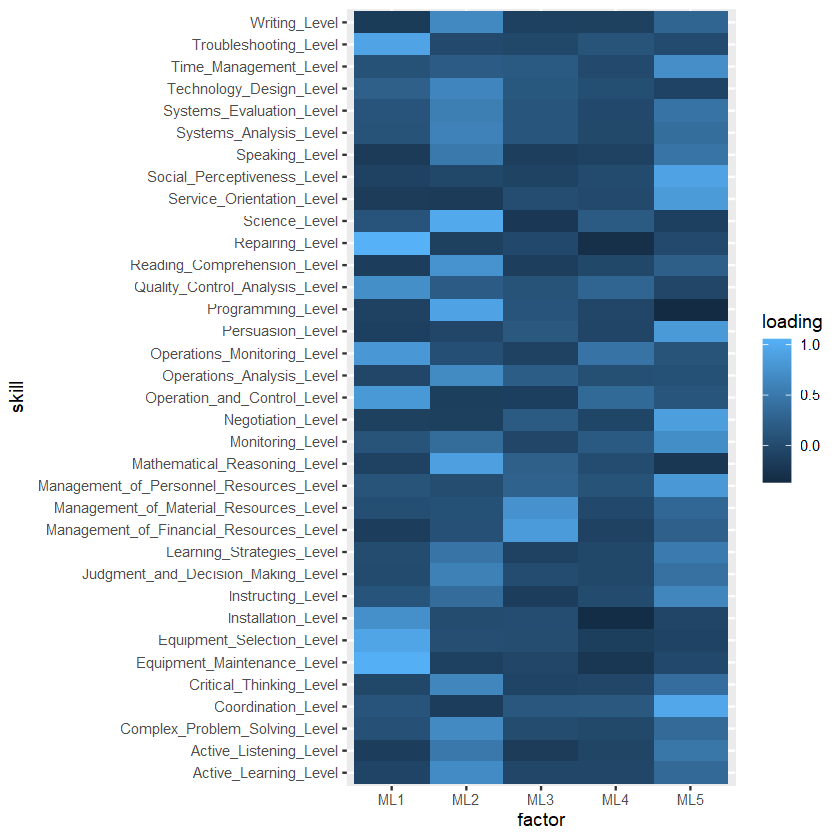

In [29]:
heatmap_2025 <- loadings_years[["2025"]] %>%
  pivot_longer(
    -skill,
    names_to = "factor",
    values_to = "loading"
  )

ggplot(
  heatmap_2025,
  aes(
    factor,
    skill,
    fill = loading
  )
) +
  geom_tile()

In [34]:
class(efa_years[["2017"]])

[1] "psych" "fa"

In [35]:
names(efa_years[["2017"]])

[1] "residual"      "dof"           "chi"           "nh"           
 [5] "rms"           "EPVAL"         "crms"          "EBIC"         
 [9] "ESABIC"        "fit"           "fit.off"       "sd"           
[13] "factors"       "complexity"    "n.obs"         "objective"    
[17] "criteria"      "STATISTIC"     "PVAL"          "Call"         
[21] "null.model"    "null.dof"      "null.chisq"    "TLI"          
[25] "CFI"           "RMSEA"         "BIC"           "SABIC"        
[29] "r.scores"      "R2"            "valid"         "score.cor"    
[33] "weights"       "stats"         "rotation"      "hyperplane"   
[37] "communality"   "communalities" "uniquenesses"  "values"       
[41] "e.values"      "loadings"      "model"         "fm"           
[45] "rot.mat"       "Phi"           "Structure"     "method"       
[49] "scores"        "R2.scores"     "r"             "np.obs"       
[53] "fn"            "rotated"       "Vaccounted"    "ECV"

In [36]:
cong_1719 <- factor.congruence(
  efa_years[["2017"]]$loadings,
  efa_years[["2019"]]$loadings
)

cong_1719

,ML2,ML5,ML1,ML3,ML4
ML2,1.00,0.33,-0.04,-0.03,-0.01
ML5,0.25,1.00,-0.02,0.19,0.04
ML1,-0.03,-0.01,1.00,-0.06,0.10
ML3,0.01,0.17,-0.06,1.00,-0.08
ML4,-0.02,0.06,0.08,-0.10,1.00


In [37]:
loadings_2025 <- as.data.frame(
  unclass(
    efa_years[["2025"]]$loadings
  )
)

loadings_2025$skill <- rownames(loadings_2025)

loadings_2025

,ML5,ML2,ML1,ML3,ML4,skill
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Reading_Comprehension_Level,0.227803020,0.761907278,-0.152418375,-0.14041594,-0.0376358749,Reading_Comprehension_Level
Active_Listening_Level,0.474866041,0.491794621,-0.145903056,-0.16041472,-0.0651932798,Active_Listening_Level
Writing_Level,0.288950658,0.657750022,-0.167780551,-0.10689042,-0.1094543356,Writing_Level
Speaking_Level,0.449902715,0.501958932,-0.177275477,-0.13364080,-0.0943497100,Speaking_Level
Mathematical_Reasoning_Level,-0.225998903,0.880349568,-0.091973459,0.23641659,0.0227862917,Mathematical_Reasoning_Level
Science_Level,-0.112069219,0.974225763,0.110191896,-0.20960487,0.1795003083,Science_Level
Critical_Thinking_Level,0.389251773,0.629183005,-0.036555926,-0.07164660,-0.0488433240,Critical_Thinking_Level
Active_Learning_Level,0.330521760,0.679383999,-0.067323302,-0.05291271,-0.0490157437,Active_Learning_Level
Learning_Strategies_Level,0.514514619,0.448137030,0.014251495,-0.09321811,-0.0342917350,Learning_Strategies_Level


In [38]:
comm_2025 <- data.frame(
  skill = rownames(efa_years[["2025"]]$loadings),
  h2 = efa_years[["2025"]]$communality,
  u2 = efa_years[["2025"]]$uniquenesses
)

arrange(comm_2025, h2)

,skill,h2,u2
,<chr>,<dbl>,<dbl>
Technology_Design_Level,Technology_Design_Level,0.4591568,0.540843220
Installation_Level,Installation_Level,0.4916335,0.508366473
Programming_Level,Programming_Level,0.5657487,0.434251325
Operations_Analysis_Level,Operations_Analysis_Level,0.6503797,0.349620253
Service_Orientation_Level,Service_Orientation_Level,0.6843065,0.315693542
Science_Level,Science_Level,0.7043865,0.295613530
Mathematical_Reasoning_Level,Mathematical_Reasoning_Level,0.7071231,0.292876868
Coordination_Level,Coordination_Level,0.7155993,0.284400674
Instructing_Level,Instructing_Level,0.7407616,0.259238418
